In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

print('✅ All libraries imported!')

✅ All libraries imported!


In [16]:

df = pd.read_csv('../heart-decease.csv', na_values='?')


df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [18]:
#preprocessing
#fix the missing value

df['ca'].fillna(df['ca'].median(), inplace=True)
df['thal'].fillna(df['thal'].median(), inplace=True)

In [20]:
#binarise the target
df['target'] = (df['target'] > 0).astype(int)

In [21]:
#encode categorical columns
df['ca']   = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

df = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'ca', 'thal'], drop_first=True)

In [22]:
#split features and target
X = df.drop('target', axis=1)
y = df['target']

In [23]:
#train/test and split scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=X.columns)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 242
Testing  samples : 61


In [24]:
#train the model
lr_model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print('Model trained!')

Model trained!


In [26]:
#predictions
lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

In [28]:
#evaluation matrics

lr_accuracy  = accuracy_score(y_test,  lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall    = recall_score(y_test,    lr_pred)
lr_f1        = f1_score(y_test,        lr_pred)
lr_auc       = roc_auc_score(y_test,   lr_pred_proba)

print(f'Accuracy  : {lr_accuracy:.4f}')
print(f'Precision : {lr_precision:.4f}')
print(f'Recall    : {lr_recall:.4f}')
print(f'F1-Score  : {lr_f1:.4f}')
print(f'AUC-ROC   : {lr_auc:.4f}')

Accuracy  : 0.8525
Precision : 0.8276
Recall    : 0.8571
F1-Score  : 0.8421
AUC-ROC   : 0.9513


In [29]:
#classification_report
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.88      0.85      0.86        33
     Disease       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



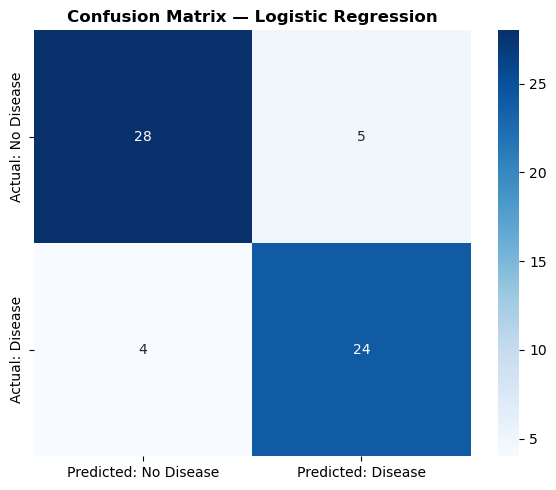

TN=28  FP=5  FN=4  TP=24


In [30]:
#confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
tn, fp, fn, tp = cm_lr.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Disease', 'Predicted: Disease'],
            yticklabels=['Actual: No Disease',    'Actual: Disease'])
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_LR.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

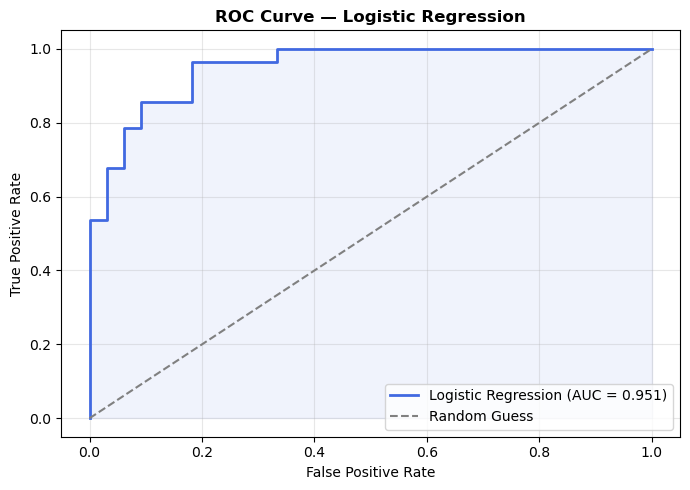

In [31]:
#ROC curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='royalblue', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guess')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='royalblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_LR.png', dpi=150, bbox_inches='tight')
plt.show()

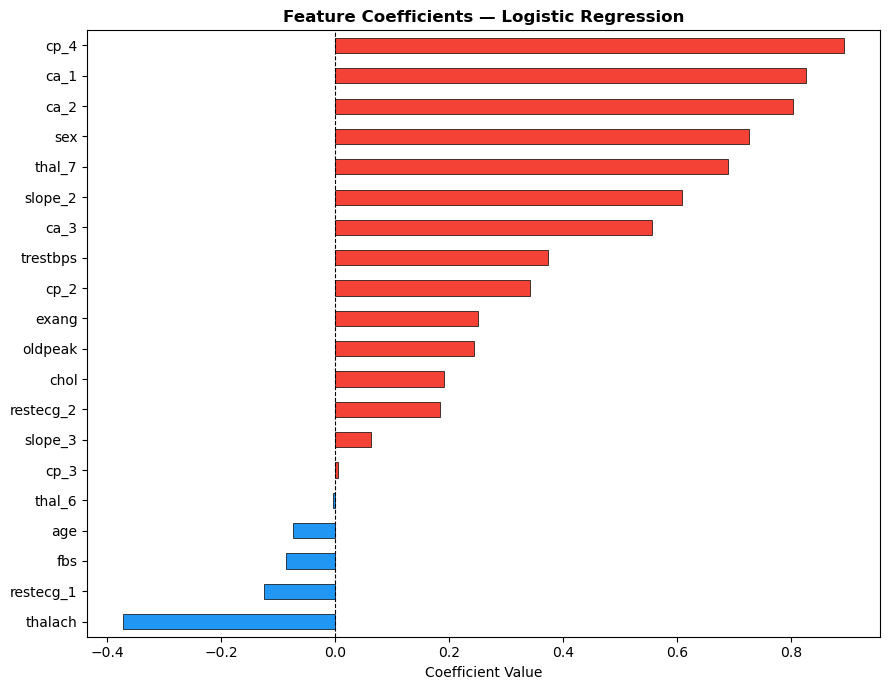

In [32]:
#feature coefficient
coefficients = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
colors = ['#F44336' if c > 0 else '#2196F3' for c in coefficients]

plt.figure(figsize=(9, 7))
coefficients.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — Logistic Regression', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_coefficients_LR.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
#cross-validation
lr_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(lr_cv_pipeline, X, y, cv=5, scoring='accuracy')

for i, score in enumerate(cv_scores, 1):
    print(f'Fold {i}: {score:.4f}')
print(f'\nMean : {cv_scores.mean():.4f}')
print(f'Std  : {cv_scores.std():.4f}')



Fold 1: 0.8852
Fold 2: 0.8852
Fold 3: 0.8197
Fold 4: 0.8500
Fold 5: 0.7667

Mean : 0.8414
Std  : 0.0447


In [34]:
lr_results = {
    'Algorithm' : 'Logistic Regression',
    'Accuracy'  : round(lr_accuracy,  4),
    'Precision' : round(lr_precision, 4),
    'Recall'    : round(lr_recall,    4),
    'F1-Score'  : round(lr_f1,        4),
    'AUC-ROC'   : round(lr_auc,       4),
}

print(lr_results)
print('\n Logistic Regression complete!')

{'Algorithm': 'Logistic Regression', 'Accuracy': 0.8525, 'Precision': 0.8276, 'Recall': 0.8571, 'F1-Score': 0.8421, 'AUC-ROC': np.float64(0.9513)}

 Logistic Regression complete!
